# Grafica Pendiente vs Elevacion



Codigo para graficar el cambio de la pendiente de acuerdo con la elevacion, considerando la frecuencia de las celdas. Graficas utilizadas por *Wegmann, S. F. G., Franke, K. L., Hughes, S., Lewis, R. Q., Lyons, N., Paris, P., Ross, K., Bauer, J. B., & Witt, A. C. (2011). Hillslope response to knickpoint migration in the Southern Appalachians: Implications for the evolution of post-orogenic landscapes. Earth Surface Processes and Landforms, 36(9), 1254–1267. https://doi.org/10.1002/esp.2150*

In [ ]:
import pip
pip.main(['install','richdem'])

In [1]:
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import DataFrame
import geopandas as gpd

import warnings
warnings.filterwarnings("ignore")

### Cuenca a analizar

,fid,DN,theta,geometry
0,14.0,100,0.383,"POLYGON ((528706.312 899150.625, 528718.812 89..."


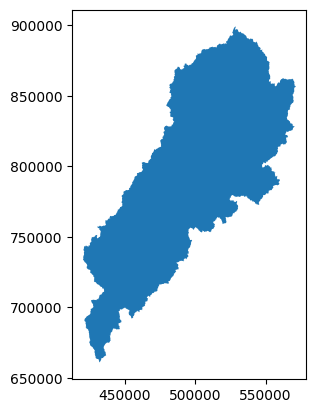

In [2]:
cuenca=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Vector/nechi_12m.shp')
cuenca.plot()
cuenca.head(2)

(93827348,)

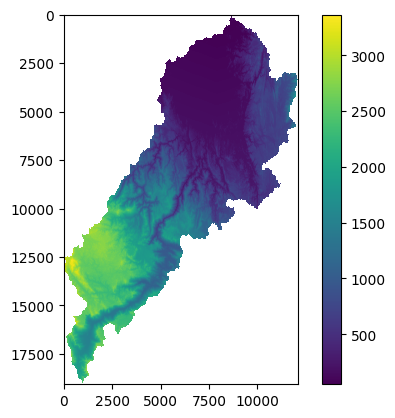

In [3]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Raster/nechi_12m_clipped.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
alt_vector_MenM=alt_vector[~np.isnan(alt_vector)] # para eliminar  del vector los datos NaN
plt.imshow(alt)
plt.colorbar();
alt_vector_MenM.shape # otra forma de saber las dimensiones

(93857033,)

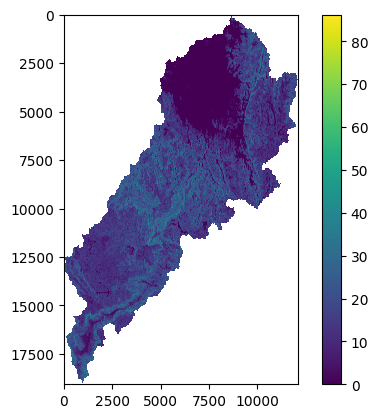

In [4]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Raster/nechi_12m_slope.tif')
pendiente=raster.read(1)
pendiente=np.where(pendiente==-9999.,np.nan,pendiente)
pendiente_vector=pendiente.ravel()
pendiente_vector_MenM=pendiente_vector[~np.isnan(pendiente_vector)]
plt.imshow(pendiente)
plt.colorbar();
pendiente_vector_MenM.shape

In [5]:
pend_serie=pd.Series(pendiente_vector,name="pend")
alt_serie=pd.Series(alt_vector,name="alt")
df=pd.merge(alt_serie,pend_serie, right_index=True, left_index=True)
df.head()

,alt,pend
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


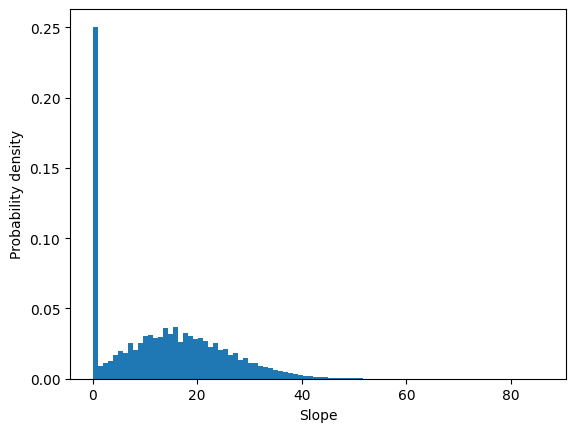

In [6]:
f, ax = plt.subplots()
ax.hist(df["pend"],bins=90, density=True)
ax.set_xlabel('Slope')
ax.set_ylabel('Probability density');

### MenM recientes

,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,date,source,elevation1,geometry
0,NaN,NaN,NaT,NaT,NaT,NaN,-1,0,-1,NaN,NaN,09/2006,My Places — _Points_,2363.0,POINT Z (439722.005 681812.005 0.000)
1,NaN,NaN,NaT,NaT,NaT,NaN,-1,0,-1,NaN,NaN,09/2011,My Places — _Points_,2881.0,POINT Z (437541.797 675246.253 0.000)


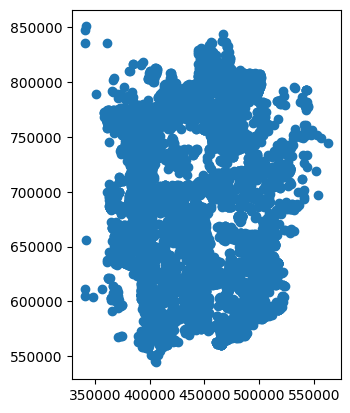

In [7]:
elevation=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent2_elev.gpkg')
elevation.plot()
elevation.head(2)

In [8]:
elevation.columns

Index(['Name', 'description', 'timestamp', 'begin', 'end', 'altitudeMode',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'date',
       'source', 'elevation1', 'geometry'],
      dtype='object')

In [9]:
rec_ele=elevation.drop(['Name', 'description', 'timestamp', 'begin', 'end', 'altitudeMode',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'date',
       'source',],axis=1)
rec_ele.rename(columns={"elevation1":"elevation"}, inplace=True)
rec_ele.head(2)

,elevation,geometry
0,2363.0,POINT Z (439722.005 681812.005 0.000)
1,2881.0,POINT Z (437541.797 675246.253 0.000)


,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,icon,fid,source,slope1,geometry
0,04102104,NaN,NaN,NaN,NaN,NaN,-1,0,0,NaN,NaN,NaN,NaN,21.813551,POINT Z (396830.971 607075.479 0.000)
1,04012014,NaN,NaN,NaN,NaN,NaN,-1,0,0,NaN,NaN,NaN,NaN,41.983601,POINT Z (396694.593 607248.860 0.000)


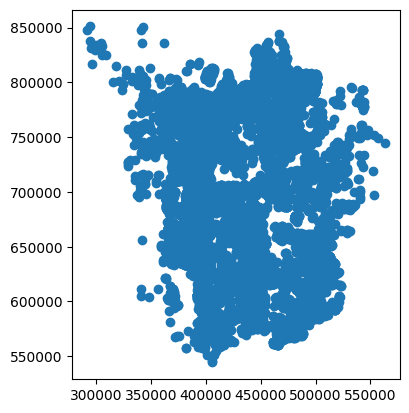

In [12]:
slope=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent2_slope_12m.shp')
slope.plot()
slope.head(2)

In [14]:
slope.columns

Index(['Name', 'descriptio', 'timestamp', 'begin', 'end', 'altitudeMo',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'fid',
       'source', 'slope1', 'geometry'],
      dtype='object')

In [15]:
rec_slop=slope.drop(['Name', 'descriptio', 'timestamp', 'begin', 'end', 'altitudeMo',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'fid',
       'source',],axis=1)
rec_slop=rec_slop.to_crs(epsg=32618)
rec_slop.rename(columns={"slope1":"slope"}, inplace=True)
rec_slop.head(2)

,slope,geometry
0,21.813551,POINT Z (396830.971 607075.479 0.000)
1,41.983601,POINT Z (396694.593 607248.860 0.000)


In [16]:
rec=pd.merge(rec_slop,rec_ele, right_index=True, left_index=True)
rec=rec.set_geometry(rec.geometry_y)
rec.drop(['geometry_x','geometry_y'],axis=1,inplace=True)
rec.head()

,slope,elevation,geometry
0,21.813551,2363.0,POINT Z (439722.005 681812.005 0.000)
1,41.983601,2881.0,POINT Z (437541.797 675246.253 0.000)
2,35.987862,1745.0,POINT Z (435725.072 679870.905 0.000)
3,20.201839,1799.0,POINT Z (434839.959 679884.566 0.000)
4,29.503712,1791.0,POINT Z (433393.875 679576.544 0.000)


<Axes: >

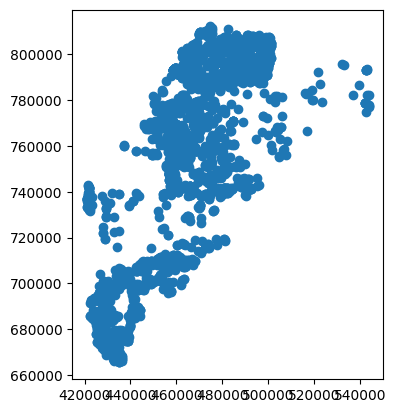

In [17]:
rec_cuenca = gpd.sjoin(rec, cuenca, how="inner", op='intersects')
rec_cuenca.plot()

### MenM Relictos

,Name,elevation1,geometry
0,El Guasimo,777.0,POINT Z (-75.86709 6.80850 753.10776)
1,El Noral,1613.0,POINT Z (-75.50832 6.36266 1592.60560)


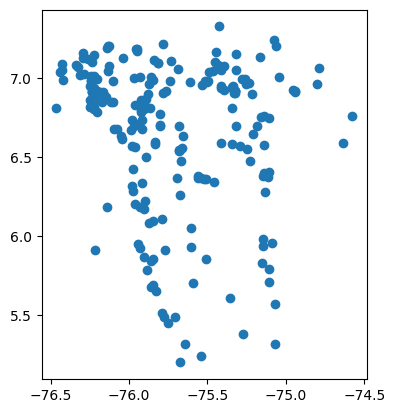

In [18]:
elevation=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_elevation.gpkg')
elevation.plot()
elevation.head(2)

In [19]:
rel_ele=elevation.drop(["Name"],axis=1)
rel_ele=rel_ele.to_crs(epsg=32618)
rel_ele.rename(columns={"elevation1":"elevation"}, inplace=True)
rel_ele.head(2)

,elevation,geometry
0,777.0,POINT Z (404187.110 752665.590 753.108)
1,1613.0,POINT Z (443782.345 703321.444 1592.606)


,Name,slope1,geometry
0,El Guasimo,15.119460,POINT Z (-75.86709 6.80850 753.10776)
1,El Noral,13.873369,POINT Z (-75.50832 6.36266 1592.60560)


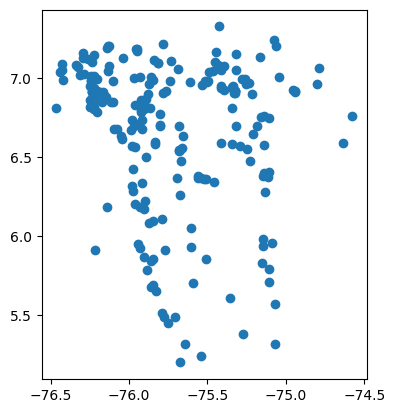

In [20]:
slope=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_slope_12m.gpkg')
slope.plot()
slope.head(2)

In [21]:
rel_slop=slope.drop(['Name'],axis=1)
rel_slop=rel_slop.to_crs(epsg=32618)
rel_slop.rename(columns={"slope1":"slope"}, inplace=True)
#rel_slop.head(2)

In [22]:
rel=pd.merge(rel_slop,rel_ele, right_index=True, left_index=True)
rel=rel.set_geometry(rel.geometry_y)
rel.drop(['geometry_x','geometry_y'],axis=1,inplace=True)
#rel.head()

In [23]:
rel_cuenca = gpd.sjoin(rel, cuenca, how="inner", op='intersects')
#rel_cuenca.plot()

### Calcular Pendiente vs elevacion

In [24]:
from math import ceil
dx=(alt_serie.max()-alt_serie.min())/99
sorted_df = df.sort_values(by=['alt'], ascending=True)
alt ={}
pend={}
total=0
for x,y in zip(sorted_df["alt"], sorted_df["pend"]):
    if (pd.isna(x))or(pd.isna(y)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
    pend.setdefault(k, []).append(y)
b = list(alt.values())
c = list(pend.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
hypso=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))
  hypso.append(len(b[x])/total)

# calculate the mean, max, min, frequency
pend_mean=[]
pend_std=[]
pend_min=[]
pend_max=[]
pend_freq=[]
for x in range(len(c)):
  pend_mean.append(np.mean(c[x]))
  pend_std.append(np.std(c[x]))
  pend_min.append(min(c[x]))
  pend_max.append(max(c[x]))
  pend_freq.append(len(c[x]))

#calcular la desviacion estandar de la pendiente
std1=[a_i - b_i for a_i, b_i in zip(pend_mean, pend_std)]
std2=[a_i + b_i for a_i, b_i in zip(pend_mean, pend_std)]

# calcular el acumulado de cuva hipsometrica
hypso_cum=1-np.cumsum(hypso)

### Figura

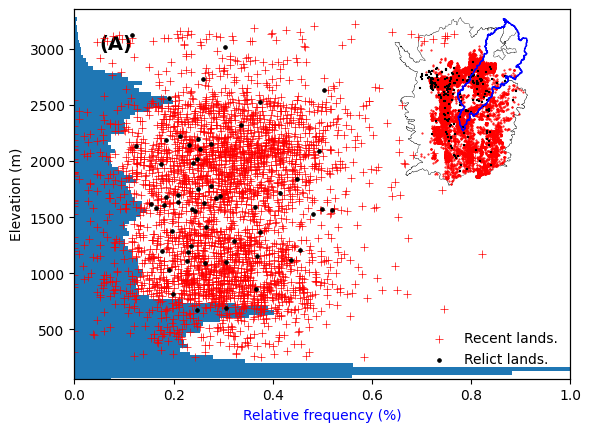

In [25]:
f, ax = plt.subplots()

ax1=ax.twiny()
#ax1.plot(pend_mean,alt_mean,'g-',label="Mean slope")
#ax1.plot(std1,alt_mean,'k--',linewidth=0.5,alpha=0.5,label="Std")
#ax1.plot(std2,alt_mean,'k--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_min,alt_mean,'g--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_max,alt_mean,'g--',linewidth=0.5,alpha=0.4,label="Max. slope")
ax1.scatter(rec_cuenca.slope,rec_cuenca.elevation,color='r',marker='+',s=30,linewidths=0.5,label='Recent lands.')
ax1.scatter(rel_cuenca.slope,rel_cuenca.elevation,color='k',marker='.',s=30,linewidths=0.5,label='Relict lands.')
ax1.set_xlim(0,90)
#ax1.set_xlabel("Mean slope (°)",color='green')
ax1.set_ylim(top=max(alt_mean),bottom=min(alt_mean))
ax1.set_xticks([])

frequency=[15*x/(total) for x in alt_freq] # se multiplica por 0.1 el denominador para que se vea mas la frecuencia en la grafica (multiplicar x10)
ax.barh(alt_mean,frequency, height=40)
ax.set_ylabel('Elevation (m)')
ax.set_xlabel("Relative frequency (%)",color='blue')
ax.set_xlim(0,10)
#ax.plot(hypso_cum,alt_mean,'k-',label="hypsometric curve")
ax.set_xlim(0,1)
ax.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

axin=ax.inset_axes([0.52,0.5,0.52,0.5])
aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
rec.plot(ax=axin,marker='.',color='red',markersize=1)
rel.plot(ax=axin,marker='+',color='black',markersize=1)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Nechi/Vector/nechi_12m.gpkg")
cat.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
axin.set_axis_off()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, ncol=1, loc="lower right",prop={'size': 10},frameon=False)
ax.text(0.05,3000,'(A)',size=14,weight='bold')

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/nechi_elev_slope_B.png");

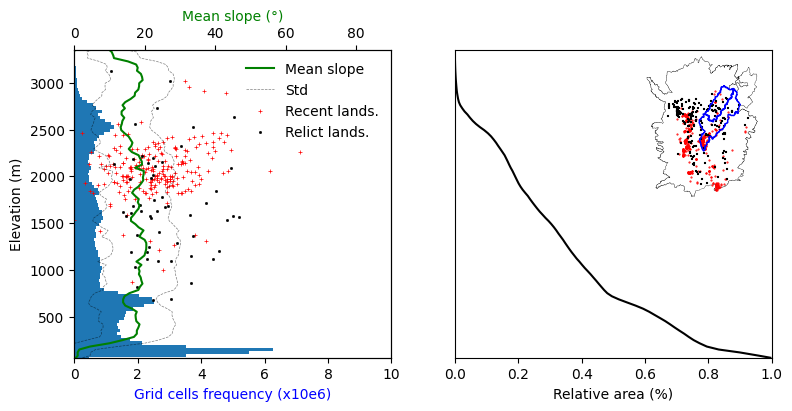

In [24]:
f, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
axs = axs.flatten()

#Subplot 1
ax=axs[0]
ax1=ax.twiny()
ax1.plot(pend_mean,alt_mean,'g-',label="Mean slope")
ax1.plot(std1,alt_mean,'k--',linewidth=0.5,alpha=0.5,label="Std")
ax1.plot(std2,alt_mean,'k--',linewidth=0.5,alpha=0.5)
ax1.plot(pend_min,alt_mean,'g--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_max,alt_mean,'g--',linewidth=0.5,alpha=0.4,label="Max. slope")
ax1.scatter(rec_cuenca.slope,rec_cuenca.elevation,color='r',marker='+',s=20,linewidths=0.5,label='Recent lands.')
ax1.scatter(rel_cuenca.slope,rel_cuenca.elevation,color='k',marker='.',s=20,linewidths=0.5,label='Relict lands.')
ax1.set_xlim(0,90)
ax1.set_xlabel("Mean slope (°)",color='green')
ax1.set_ylim(top=max(alt_mean),bottom=min(alt_mean))
frequency=[x/1000000 for x in alt_freq]
ax.barh(alt_mean,frequency, height=40)
ax.set_ylabel('Elevation (m)')
ax.set_xlabel("Grid cells frequency (x10e6)",color='blue')
ax.set_xlim(0,10)
plt.legend(ncol=1, loc='upper right',prop={'size': 10},frameon=False)

#subplot 2
hypso_cum=1-np.cumsum(hypso)
ax=axs[1]
#ax.plot(hypso_cum,alt_mean,'k-',label="hypsometric curve")
ax.set_xlim(0,1)
ax.set_ylim(top=max(alt_mean),bottom=min(alt_mean))
ax.set_yticks([])
ax.set_xlabel('Relative area (%)')

axin=ax.inset_axes([0.52,0.5,0.52,0.5])
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/cuencas_areaestudio.shp")
aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
rec.plot(ax=axin,marker='.',color='red',markersize=1)
rel.plot(ax=axin,marker='+',color='black',markersize=1)
focus = cat.loc[[46], ['geometry']]
focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
focus = cat.loc[[18], ['geometry']]
focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
axin.set_axis_off()

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/nechi_elev_slope_double.png");

### Dona Maria

<Axes: >

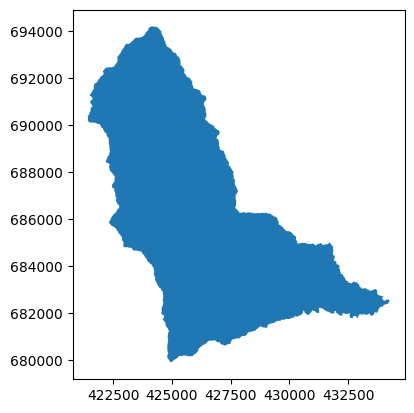

In [25]:
cuenca=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Vector/donaMaria_12m.shp')
cuenca.plot()

(471066,)

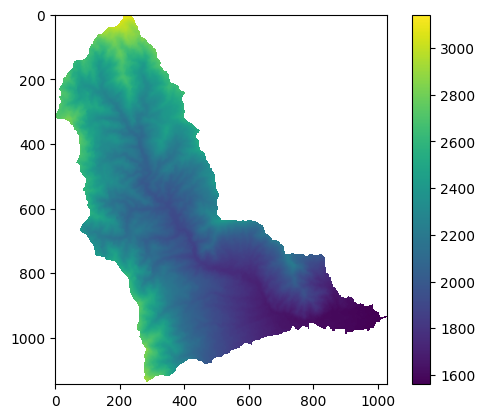

In [26]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/donaMaria_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
alt_vector_MenM=alt_vector[~np.isnan(alt_vector)] # para eliminar  del vector los datos NaN
plt.imshow(alt)
plt.colorbar();
alt_vector_MenM.shape # otra forma de saber las dimensiones

(472476,)

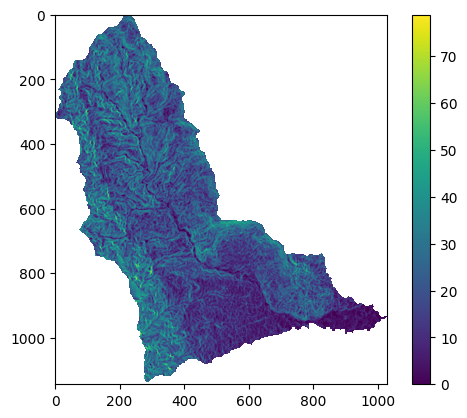

In [27]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/donaMaria_slope_12m.tif')
pendiente=raster.read(1)
pendiente=np.where(pendiente==-9999.,np.nan,pendiente)
pendiente_vector=pendiente.ravel()
pendiente_vector_MenM=pendiente_vector[~np.isnan(pendiente_vector)]
plt.imshow(pendiente)
plt.colorbar();
pendiente_vector_MenM.shape

In [28]:
pend_serie=pd.Series(pendiente_vector,name="pend")
alt_serie=pd.Series(alt_vector,name="alt")
df=pd.merge(alt_serie,pend_serie, right_index=True, left_index=True)
df.head()

,alt,pend
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


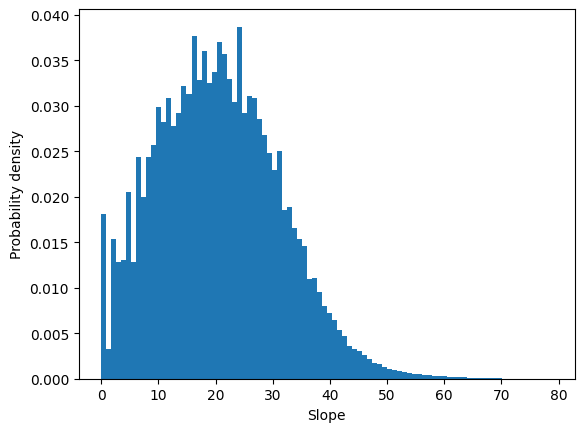

In [29]:
f, ax = plt.subplots()
ax.hist(df["pend"],bins=90, density=True)
ax.set_xlabel('Slope')
ax.set_ylabel('Probability density');

<Axes: >

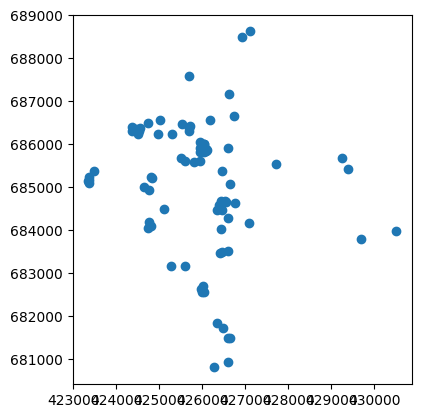

In [30]:
rec_cuenca = gpd.sjoin(rec, cuenca, how="inner", op='intersects')
rec_cuenca.plot()

<Axes: >

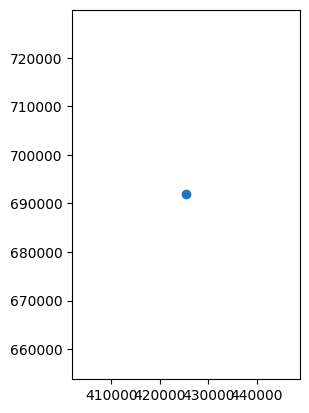

In [31]:
rel_cuenca = gpd.sjoin(rel, cuenca, how="inner", op='intersects')
rel_cuenca.plot()

In [32]:
dx=(alt_serie.max()-alt_serie.min())/99
sorted_df = df.sort_values(by=['alt'], ascending=True)
alt ={}
pend={}
total=0
for x,y in zip(sorted_df["alt"], sorted_df["pend"]):
    if (pd.isna(x))or(pd.isna(y)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
    pend.setdefault(k, []).append(y)
b = list(alt.values())
c = list(pend.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
hypso=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))
  hypso.append(len(b[x])/total)

# calculate the mean, max, min, frequency
pend_mean=[]
pend_std=[]
pend_min=[]
pend_max=[]
pend_freq=[]
for x in range(len(c)):
  pend_mean.append(np.mean(c[x]))
  pend_std.append(np.std(c[x]))
  pend_min.append(min(c[x]))
  pend_max.append(max(c[x]))
  pend_freq.append(len(c[x]))

#calcular la desviacion estandar de la pendiente
std1=[a_i - b_i for a_i, b_i in zip(pend_mean, pend_std)]
std2=[a_i + b_i for a_i, b_i in zip(pend_mean, pend_std)]

# calcular el acumulado de cuva hipsometrica
hypso_cum=1-np.cumsum(hypso)

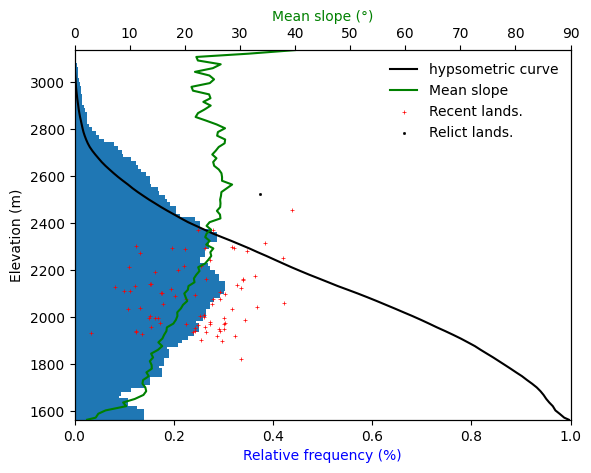

In [33]:
f, ax = plt.subplots()

ax1=ax.twiny()
ax1.plot(pend_mean,alt_mean,'g-',label="Mean slope")
#ax1.plot(std1,alt_mean,'k--',linewidth=0.5,alpha=0.5,label="Std")
#ax1.plot(std2,alt_mean,'k--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_min,alt_mean,'g--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_max,alt_mean,'g--',linewidth=0.5,alpha=0.4,label="Max. slope")
ax1.scatter(rec_cuenca.slope,rec_cuenca.elevation,color='r',marker='+',s=10,linewidths=0.5,label='Recent lands.')
ax1.scatter(rel_cuenca.slope,rel_cuenca.elevation,color='k',marker='.',s=10,linewidths=0.5,label='Relict lands.')
ax1.set_xlim(0,90)
ax1.set_xlabel("Mean slope (°)",color='green')
ax1.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

frequency=[15*x/(total) for x in alt_freq] # se multiplica por 0.1 el denominador para que se vea mas la frecuencia en la grafica (multiplicar x10)
ax.barh(alt_mean,frequency, height=40)
ax.set_ylabel('Elevation (m)')
ax.set_xlabel("Relative frequency (%)",color='blue')
ax.set_xlim(0,10)
ax.plot(hypso_cum,alt_mean,'k-',label="hypsometric curve")
ax.set_xlim(0,1)
ax.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

#axin=ax.inset_axes([0.52,0.5,0.52,0.5])
#cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/cuencas_areaestudio.shp")
#aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
#aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
#rec.plot(ax=axin,marker='.',color='red',markersize=1)
#rel.plot(ax=axin,marker='+',color='black',markersize=1)
#focus = cat.loc[[46], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#focus = cat.loc[[18], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#axin.set_axis_off()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, ncol=1, loc="upper right",prop={'size': 10},frameon=False)

#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/donaMaria_elev_slope_B.png");

### La Iguana

<Axes: >

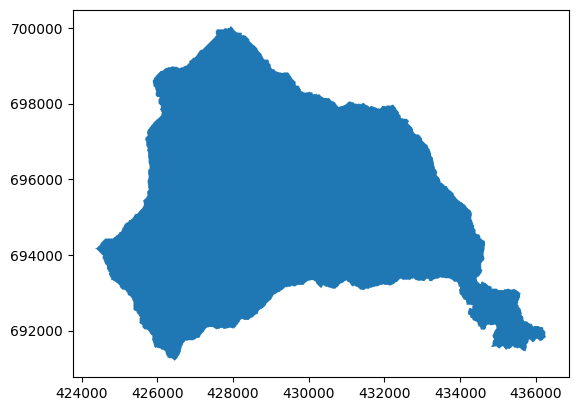

In [34]:
cuenca=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Vector/iguana_12m.shp')
cuenca.plot()

(329650,)

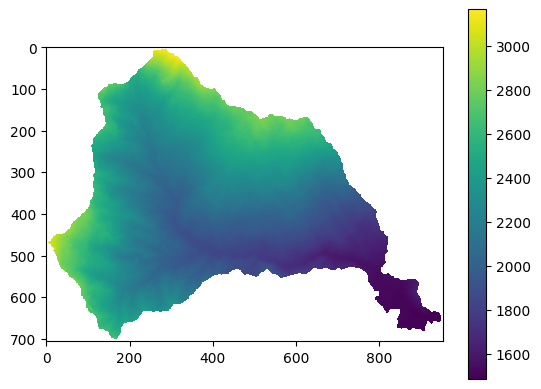

In [35]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/iguana_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
alt_vector_MenM=alt_vector[~np.isnan(alt_vector)] # para eliminar  del vector los datos NaN
plt.imshow(alt)
plt.colorbar();
alt_vector_MenM.shape # otra forma de saber las dimensiones

(330866,)

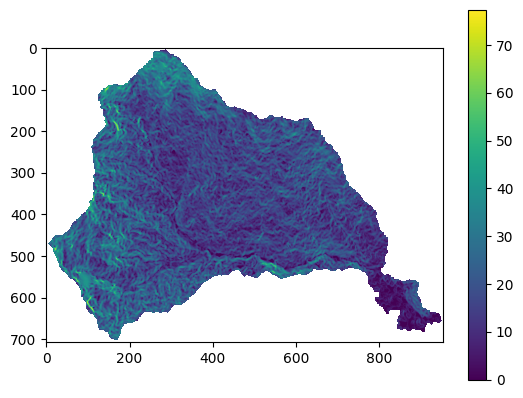

In [36]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/iguana_slope_12m.tif')
pendiente=raster.read(1)
pendiente=np.where(pendiente==-9999.,np.nan,pendiente)
pendiente_vector=pendiente.ravel()
pendiente_vector_MenM=pendiente_vector[~np.isnan(pendiente_vector)]
plt.imshow(pendiente)
plt.colorbar();
pendiente_vector_MenM.shape

In [37]:
pend_serie=pd.Series(pendiente_vector,name="pend")
alt_serie=pd.Series(alt_vector,name="alt")
df=pd.merge(alt_serie,pend_serie, right_index=True, left_index=True)
df.head()

,alt,pend
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


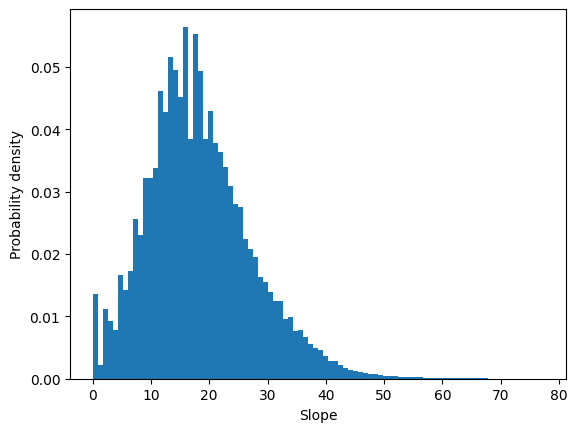

In [38]:
f, ax = plt.subplots()
ax.hist(df["pend"],bins=90, density=True)
ax.set_xlabel('Slope')
ax.set_ylabel('Probability density');

<Axes: >

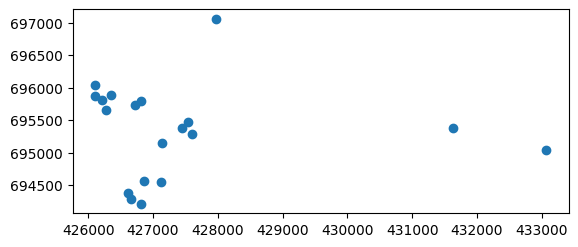

In [39]:
rec_cuenca = gpd.sjoin(rec, cuenca, how="inner", op='intersects')
rec_cuenca.plot()

<Axes: >

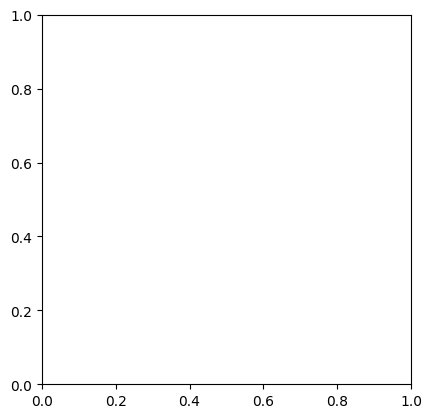

In [40]:
rel_cuenca = gpd.sjoin(rel, cuenca, how="inner", op='intersects')
rel_cuenca.plot()

In [41]:
dx=(alt_serie.max()-alt_serie.min())/99
sorted_df = df.sort_values(by=['alt'], ascending=True)
alt ={}
pend={}
total=0
for x,y in zip(sorted_df["alt"], sorted_df["pend"]):
    if (pd.isna(x))or(pd.isna(y)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
    pend.setdefault(k, []).append(y)
b = list(alt.values())
c = list(pend.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
hypso=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))
  hypso.append(len(b[x])/total)

# calculate the mean, max, min, frequency
pend_mean=[]
pend_std=[]
pend_min=[]
pend_max=[]
pend_freq=[]
for x in range(len(c)):
  pend_mean.append(np.mean(c[x]))
  pend_std.append(np.std(c[x]))
  pend_min.append(min(c[x]))
  pend_max.append(max(c[x]))
  pend_freq.append(len(c[x]))

#calcular la desviacion estandar de la pendiente
std1=[a_i - b_i for a_i, b_i in zip(pend_mean, pend_std)]
std2=[a_i + b_i for a_i, b_i in zip(pend_mean, pend_std)]

# calcular el acumulado de cuva hipsometrica
hypso_cum=1-np.cumsum(hypso)

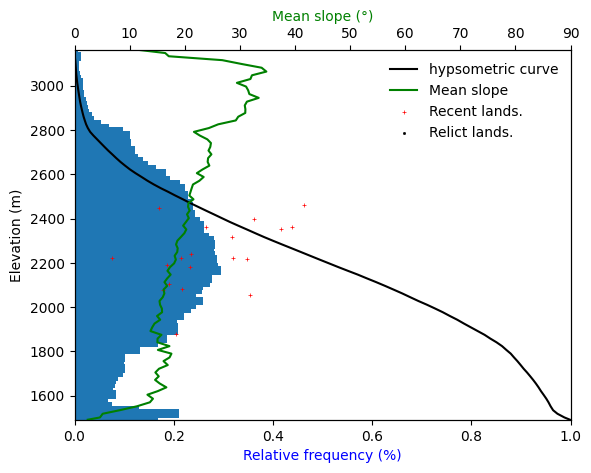

In [42]:
f, ax = plt.subplots()

ax1=ax.twiny()
ax1.plot(pend_mean,alt_mean,'g-',label="Mean slope")
#ax1.plot(std1,alt_mean,'k--',linewidth=0.5,alpha=0.5,label="Std")
#ax1.plot(std2,alt_mean,'k--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_min,alt_mean,'g--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_max,alt_mean,'g--',linewidth=0.5,alpha=0.4,label="Max. slope")
ax1.scatter(rec_cuenca.slope,rec_cuenca.elevation,color='r',marker='+',s=10,linewidths=0.5,label='Recent lands.')
ax1.scatter(rel_cuenca.slope,rel_cuenca.elevation,color='k',marker='.',s=10,linewidths=0.5,label='Relict lands.')
ax1.set_xlim(0,90)
ax1.set_xlabel("Mean slope (°)",color='green')
ax1.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

frequency=[15*x/(total) for x in alt_freq] # se multiplica por 0.1 el denominador para que se vea mas la frecuencia en la grafica (multiplicar x10)
ax.barh(alt_mean,frequency, height=40)
ax.set_ylabel('Elevation (m)')
ax.set_xlabel("Relative frequency (%)",color='blue')
ax.set_xlim(0,10)
ax.plot(hypso_cum,alt_mean,'k-',label="hypsometric curve")
ax.set_xlim(0,1)
ax.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

#axin=ax.inset_axes([0.52,0.5,0.52,0.5])
#cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/cuencas_areaestudio.shp")
#aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
#aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
#rec.plot(ax=axin,marker='.',color='red',markersize=1)
#rel.plot(ax=axin,marker='+',color='black',markersize=1)
#focus = cat.loc[[46], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#focus = cat.loc[[18], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#axin.set_axis_off()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, ncol=1, loc="upper right",prop={'size': 10},frameon=False)

#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/iguana_elev_slope_B.png");

### La Garcia

<Axes: >

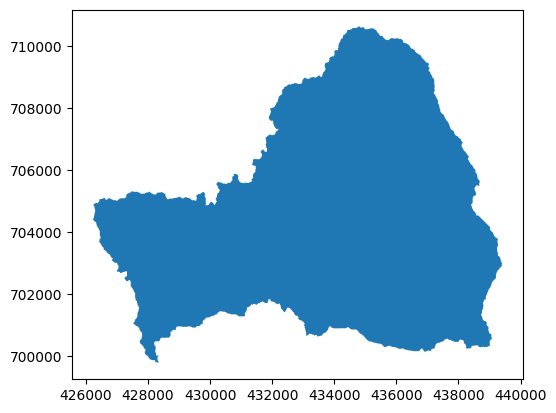

In [43]:
cuenca=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Vector/garcia_12m.shp')
cuenca.plot()

(510735,)

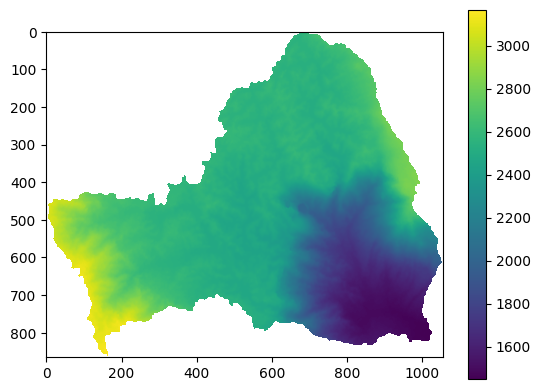

In [44]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/garcia_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
alt_vector_MenM=alt_vector[~np.isnan(alt_vector)] # para eliminar  del vector los datos NaN
plt.imshow(alt)
plt.colorbar();
alt_vector_MenM.shape # otra forma de saber las dimensiones

(512112,)

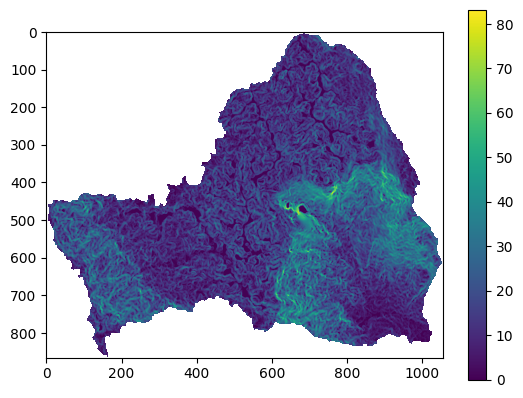

In [45]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/garcia_slope_12m.tif')
pendiente=raster.read(1)
pendiente=np.where(pendiente==-9999.,np.nan,pendiente)
pendiente_vector=pendiente.ravel()
pendiente_vector_MenM=pendiente_vector[~np.isnan(pendiente_vector)]
plt.imshow(pendiente)
plt.colorbar();
pendiente_vector_MenM.shape

In [46]:
pend_serie=pd.Series(pendiente_vector,name="pend")
alt_serie=pd.Series(alt_vector,name="alt")
df=pd.merge(alt_serie,pend_serie, right_index=True, left_index=True)
df.head(2)

,alt,pend
0,NaN,NaN
1,NaN,NaN


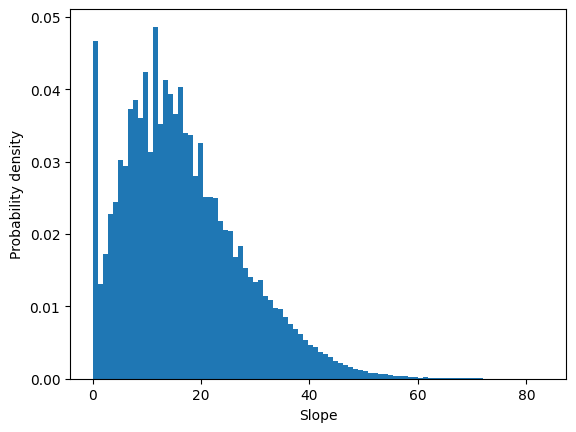

In [47]:
f, ax = plt.subplots()
ax.hist(df["pend"],bins=90, density=True)
ax.set_xlabel('Slope')
ax.set_ylabel('Probability density');

<Axes: >

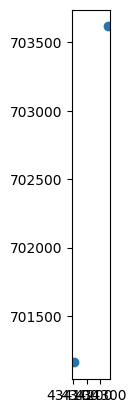

In [48]:
rec_cuenca = gpd.sjoin(rec, cuenca, how="inner", op='intersects')
rec_cuenca.plot()

<Axes: >

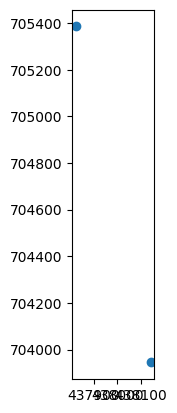

In [49]:
rel_cuenca = gpd.sjoin(rel, cuenca, how="inner", op='intersects')
rel_cuenca.plot()

In [50]:
dx=(alt_serie.max()-alt_serie.min())/99
sorted_df = df.sort_values(by=['alt'], ascending=True)
alt ={}
pend={}
total=0
for x,y in zip(sorted_df["alt"], sorted_df["pend"]):
    if (pd.isna(x))or(pd.isna(y)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
    pend.setdefault(k, []).append(y)
b = list(alt.values())
c = list(pend.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
hypso=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))
  hypso.append(len(b[x])/total)

# calculate the mean, max, min, frequency
pend_mean=[]
pend_std=[]
pend_min=[]
pend_max=[]
pend_freq=[]
for x in range(len(c)):
  pend_mean.append(np.mean(c[x]))
  pend_std.append(np.std(c[x]))
  pend_min.append(min(c[x]))
  pend_max.append(max(c[x]))
  pend_freq.append(len(c[x]))

#calcular la desviacion estandar de la pendiente
std1=[a_i - b_i for a_i, b_i in zip(pend_mean, pend_std)]
std2=[a_i + b_i for a_i, b_i in zip(pend_mean, pend_std)]

# calcular el acumulado de cuva hipsometrica
hypso_cum=1-np.cumsum(hypso)

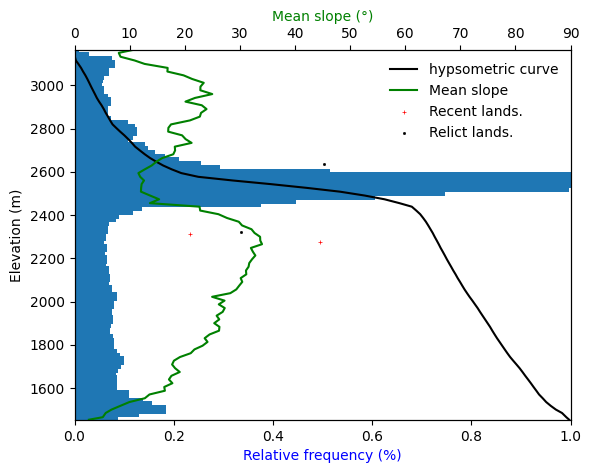

In [51]:
f, ax = plt.subplots()

ax1=ax.twiny()
ax1.plot(pend_mean,alt_mean,'g-',label="Mean slope")
#ax1.plot(std1,alt_mean,'k--',linewidth=0.5,alpha=0.5,label="Std")
#ax1.plot(std2,alt_mean,'k--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_min,alt_mean,'g--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_max,alt_mean,'g--',linewidth=0.5,alpha=0.4,label="Max. slope")
ax1.scatter(rec_cuenca.slope,rec_cuenca.elevation,color='r',marker='+',s=10,linewidths=0.5,label='Recent lands.')
ax1.scatter(rel_cuenca.slope,rel_cuenca.elevation,color='k',marker='.',s=10,linewidths=0.5,label='Relict lands.')
ax1.set_xlim(0,90)
ax1.set_xlabel("Mean slope (°)",color='green')
ax1.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

frequency=[15*x/(total) for x in alt_freq] # se multiplica por 0.1 el denominador para que se vea mas la frecuencia en la grafica (multiplicar x10)
ax.barh(alt_mean,frequency, height=40)
ax.set_ylabel('Elevation (m)')
ax.set_xlabel("Relative frequency (%)",color='blue')
ax.set_xlim(0,10)
ax.plot(hypso_cum,alt_mean,'k-',label="hypsometric curve")
ax.set_xlim(0,1)
ax.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

#axin=ax.inset_axes([0.52,0.5,0.52,0.5])
#cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/cuencas_areaestudio.shp")
#aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
#aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
#rec.plot(ax=axin,marker='.',color='red',markersize=1)
#rel.plot(ax=axin,marker='+',color='black',markersize=1)
#focus = cat.loc[[46], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#focus = cat.loc[[18], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#axin.set_axis_off()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, ncol=1, loc="upper right",prop={'size': 10},frameon=False)

#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/garcia_elev_slope_B.png");

### Santa Elena

<Axes: >

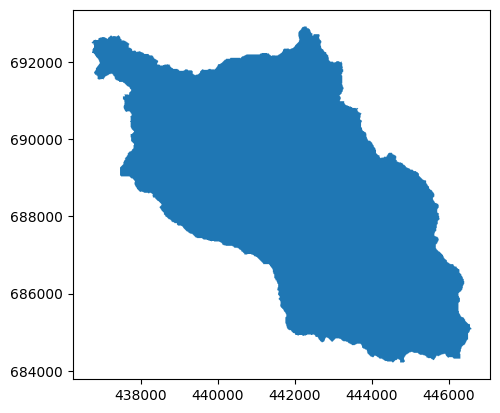

In [52]:
cuenca=gpd.read_file('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Vector/santaElena_12m.shp')
cuenca.plot()

(288439,)

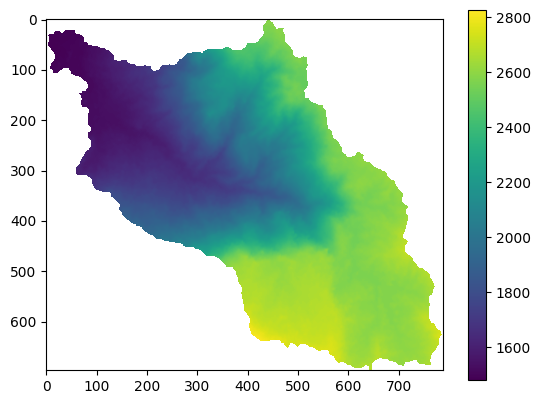

In [53]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/santaElena_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
alt_vector_MenM=alt_vector[~np.isnan(alt_vector)] # para eliminar  del vector los datos NaN
plt.imshow(alt)
plt.colorbar();
alt_vector_MenM.shape # otra forma de saber las dimensiones

(289495,)

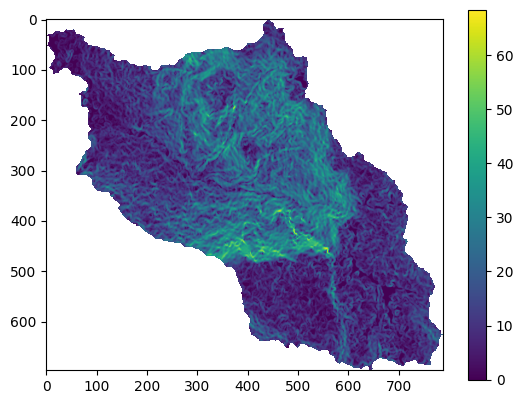

In [54]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/santaElena_slope_12m.tif')
pendiente=raster.read(1)
pendiente=np.where(pendiente==-9999.,np.nan,pendiente)
pendiente_vector=pendiente.ravel()
pendiente_vector_MenM=pendiente_vector[~np.isnan(pendiente_vector)]
plt.imshow(pendiente)
plt.colorbar();
pendiente_vector_MenM.shape

In [55]:
pend_serie=pd.Series(pendiente_vector,name="pend")
alt_serie=pd.Series(alt_vector,name="alt")
df=pd.merge(alt_serie,pend_serie, right_index=True, left_index=True)
df.head(2)

,alt,pend
0,NaN,NaN
1,NaN,NaN


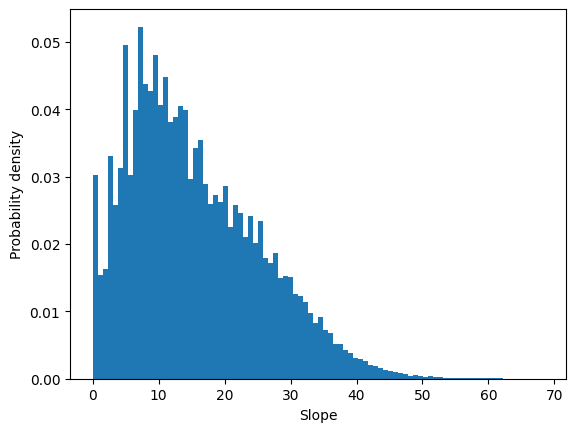

In [56]:
f, ax = plt.subplots()
ax.hist(df["pend"],bins=90, density=True)
ax.set_xlabel('Slope')
ax.set_ylabel('Probability density');

<Axes: >

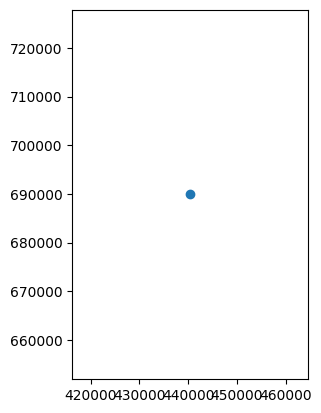

In [57]:
rec_cuenca = gpd.sjoin(rec, cuenca, how="inner", op='intersects')
rec_cuenca.plot()

<Axes: >

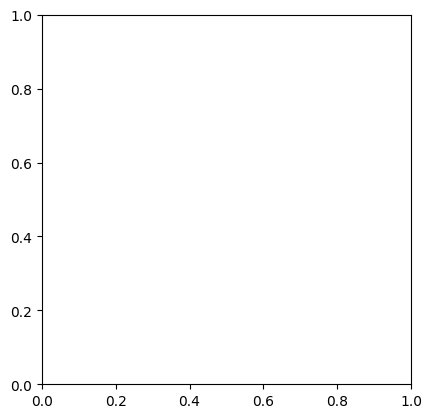

In [58]:
rel_cuenca = gpd.sjoin(rel, cuenca, how="inner", op='intersects')
rel_cuenca.plot()

In [59]:
dx=(alt_serie.max()-alt_serie.min())/99
sorted_df = df.sort_values(by=['alt'], ascending=True)
alt ={}
pend={}
total=0
for x,y in zip(sorted_df["alt"], sorted_df["pend"]):
    if (pd.isna(x))or(pd.isna(y)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
    pend.setdefault(k, []).append(y)
b = list(alt.values())
c = list(pend.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
hypso=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))
  hypso.append(len(b[x])/total)

# calculate the mean, max, min, frequency
pend_mean=[]
pend_std=[]
pend_min=[]
pend_max=[]
pend_freq=[]
for x in range(len(c)):
  pend_mean.append(np.mean(c[x]))
  pend_std.append(np.std(c[x]))
  pend_min.append(min(c[x]))
  pend_max.append(max(c[x]))
  pend_freq.append(len(c[x]))

#calcular la desviacion estandar de la pendiente
std1=[a_i - b_i for a_i, b_i in zip(pend_mean, pend_std)]
std2=[a_i + b_i for a_i, b_i in zip(pend_mean, pend_std)]

# calcular el acumulado de cuva hipsometrica
hypso_cum=1-np.cumsum(hypso)

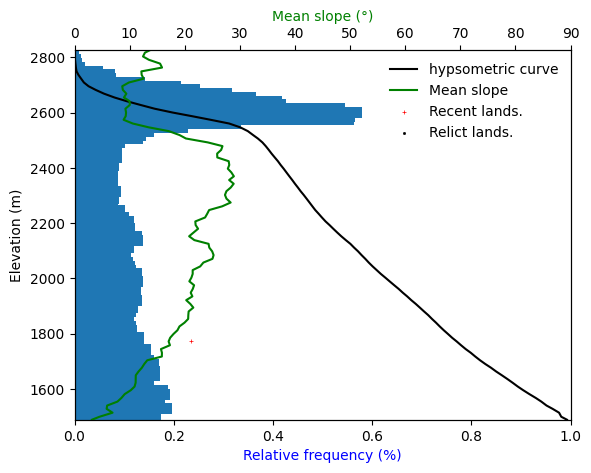

In [60]:
f, ax = plt.subplots()

ax1=ax.twiny()
ax1.plot(pend_mean,alt_mean,'g-',label="Mean slope")
#ax1.plot(std1,alt_mean,'k--',linewidth=0.5,alpha=0.5,label="Std")
#ax1.plot(std2,alt_mean,'k--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_min,alt_mean,'g--',linewidth=0.5,alpha=0.5)
#ax1.plot(pend_max,alt_mean,'g--',linewidth=0.5,alpha=0.4,label="Max. slope")
ax1.scatter(rec_cuenca.slope,rec_cuenca.elevation,color='r',marker='+',s=10,linewidths=0.5,label='Recent lands.')
ax1.scatter(rel_cuenca.slope,rel_cuenca.elevation,color='k',marker='.',s=10,linewidths=0.5,label='Relict lands.')
ax1.set_xlim(0,90)
ax1.set_xlabel("Mean slope (°)",color='green')
ax1.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

frequency=[15*x/(total) for x in alt_freq] # se multiplica por 0.1 el denominador para que se vea mas la frecuencia en la grafica (multiplicar x10)
ax.barh(alt_mean,frequency, height=40)
ax.set_ylabel('Elevation (m)')
ax.set_xlabel("Relative frequency (%)",color='blue')
ax.set_xlim(0,10)
ax.plot(hypso_cum,alt_mean,'k-',label="hypsometric curve")
ax.set_xlim(0,1)
ax.set_ylim(top=max(alt_mean),bottom=min(alt_mean))

#axin=ax.inset_axes([0.52,0.5,0.52,0.5])
#cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/cuencas_areaestudio.shp")
#aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
#aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
#rec.plot(ax=axin,marker='.',color='red',markersize=1)
#rel.plot(ax=axin,marker='+',color='black',markersize=1)
#focus = cat.loc[[46], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#focus = cat.loc[[18], ['geometry']]
#focus.plot(facecolor='none',edgecolor='blue',linewidth=1,ax=axin)
#axin.set_axis_off()

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, ncol=1, loc="upper right",prop={'size': 10},frameon=False)

#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/santaElena_elev_slope_B.png");

### Rio Guadalupe